In [1]:
!pip install -q mlflow joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pickle
import joblib
import os

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import mlflow
import mlflow.sklearn

print("All libraries imported successfully!")
print("MLflow version:", mlflow.__version__)

All libraries imported successfully!
MLflow version: 3.15.1


In [3]:
# Load Breast Cancer dataset
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("Dataset Shape:", X.shape)

print("\nFirst 5 rows:")
display(X.head())

print("\nClass Distribution:")
print(y.value_counts())

Dataset Shape: (569, 30)

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Class Distribution:
target
1    357
0    212
Name: count, dtype: int64


In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train model
model.fit(X_train, y_train)

print("Training completed successfully!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training completed successfully!
Training samples: 455
Testing samples: 114


In [5]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
average_precision = average_precision_score(y_test, y_prob)

print("Model Evaluation")
print("----------------")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")
print(f"Average Precision : {average_precision:.4f}")

Model Evaluation
----------------
Accuracy          : 0.9825
Precision         : 0.9861
Recall            : 0.9861
F1 Score          : 0.9861
ROC-AUC           : 0.9954
Average Precision : 0.9971


Confusion Matrix:
[[41  1]
 [ 1 71]]


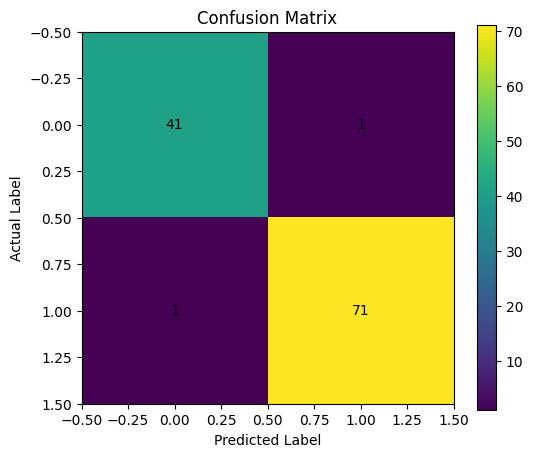

In [6]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [7]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



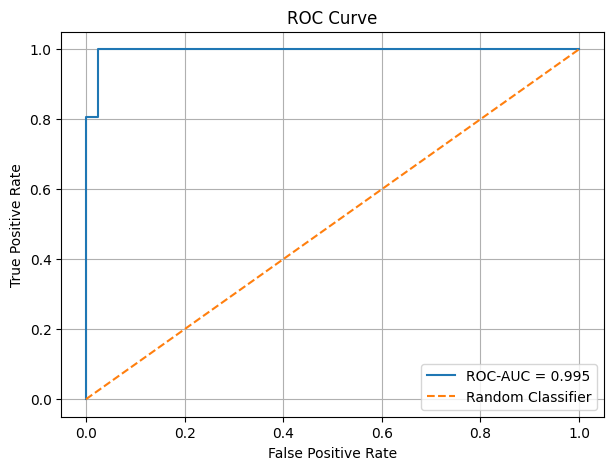

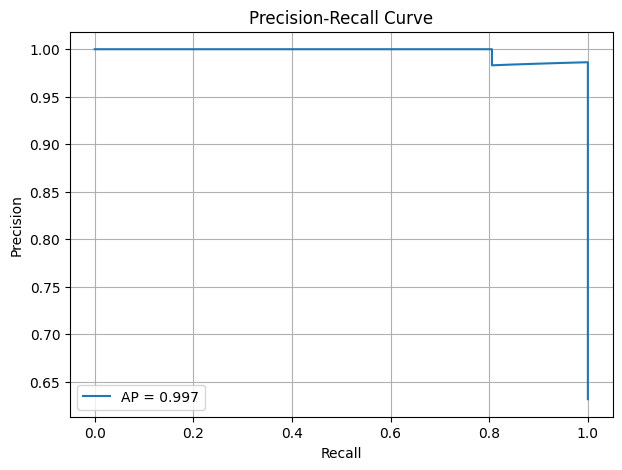

In [8]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


# Precision-Recall curve
precision_values, recall_values, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))
plt.plot(
    recall_values,
    precision_values,
    label=f"AP = {average_precision:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

In [9]:
pickle_file = "breast_cancer_model.pkl"

with open(pickle_file, "wb") as file:
    pickle.dump(model, file)

print("Model saved using Pickle.")
print("File:", pickle_file)
print("Size:", os.path.getsize(pickle_file), "bytes")

Model saved using Pickle.
File: breast_cancer_model.pkl
Size: 2682 bytes


In [10]:
# Load Pickle model
with open(pickle_file, "rb") as file:
    pickle_model = pickle.load(file)

# Predict using loaded model
pickle_predictions = pickle_model.predict(X_test)

pickle_accuracy = accuracy_score(
    y_test,
    pickle_predictions
)

print("Pickle model loaded successfully!")
print("Pickle Accuracy:", pickle_accuracy)

print(
    "Predictions identical:",
    np.array_equal(y_pred, pickle_predictions)
)

Pickle model loaded successfully!
Pickle Accuracy: 0.9824561403508771
Predictions identical: True


In [11]:
joblib_file = "breast_cancer_model.joblib"

# Save
joblib.dump(model, joblib_file)

print("Model saved using Joblib.")
print("File:", joblib_file)
print("Size:", os.path.getsize(joblib_file), "bytes")

# Load
joblib_model = joblib.load(joblib_file)

print("\nJoblib model loaded successfully!")

Model saved using Joblib.
File: breast_cancer_model.joblib
Size: 3089 bytes

Joblib model loaded successfully!


In [12]:
joblib_predictions = joblib_model.predict(X_test)

joblib_accuracy = accuracy_score(
    y_test,
    joblib_predictions
)

print("Joblib Accuracy:", joblib_accuracy)

print(
    "Predictions identical:",
    np.array_equal(y_pred, joblib_predictions)
)

Joblib Accuracy: 0.9824561403508771
Predictions identical: True


In [13]:
comparison = pd.DataFrame({
    "Model": [
        "Original Model",
        "Pickle Model",
        "Joblib Model"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, pickle_predictions),
        accuracy_score(y_test, joblib_predictions)
    ]
})

display(comparison)

,Model,Accuracy
0,Original Model,0.982456
1,Pickle Model,0.982456
2,Joblib Model,0.982456


In [14]:
# Verify all models produce exactly the same predictions

original_predictions = model.predict(X_test)
pickle_predictions = pickle_model.predict(X_test)
joblib_predictions = joblib_model.predict(X_test)

assert np.array_equal(
    original_predictions,
    pickle_predictions
)

assert np.array_equal(
    original_predictions,
    joblib_predictions
)

print("All serialization tests passed successfully!")
print("Original, Pickle and Joblib predictions are identical.")

All serialization tests passed successfully!
Original, Pickle and Joblib predictions are identical.


In [15]:
# Create MLflow experiment
mlflow.set_experiment("W4D3_Model_Serialisation")

with mlflow.start_run():

    # Log parameters
    mlflow.log_param(
        "model",
        "Logistic Regression"
    )

    mlflow.log_param(
        "pickle_file",
        pickle_file
    )

    mlflow.log_param(
        "joblib_file",
        joblib_file
    )

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Log model
    mlflow.sklearn.log_model(
        model,
        "breast_cancer_classifier"
    )

    print("MLflow tracking completed!")


# Final summary
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        average_precision
    ]
})

display(final_results)

2026/08/25 15:45:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/25 15:45:30 INFO mlflow.store.db.utils: Updating database tables
2026/08/25 15:45:33 INFO mlflow.tracking.fluent: Experiment with name 'W4D3_Model_Serialisation' does not exist. Creating a new experiment.
2026/08/25 15:45:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow tracking completed!


,Metric,Score
0,Accuracy,0.982456
1,Precision,0.986111
2,Recall,0.986111
3,F1 Score,0.986111
4,ROC-AUC,0.995370
5,Average Precision,0.997065
